<a href="https://colab.research.google.com/github/oxayavongsa/aai-iot-linear-regression/blob/main/Linear_Regression_for_IoT_Completed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Regression Analysis and Prediction for IoT

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

#suppress scientific notation in pandas
pd.set_option('display.float_format', lambda x: '%.5f' % x)

In [2]:
#use this cell to import additional libraries or define helper functions
from google.colab import drive
import zipfile
import os
from sklearn.metrics import mean_squared_error as mse

# Helper: run streaming regression for a given mu
def run_streaming_regression(ts, ys, n_s, ph, mu):
    # Arrays to store predictions
    tp_pred = np.zeros(n_s - 1)
    yp_pred = np.zeros(n_s - 1)

    for i in range(2, n_s + 1):
        # "Historical" data up to i-th sample
        ts_tmp = ts.iloc[:i, 0].values.reshape(-1, 1)
        ys_tmp = ys.iloc[:i, 0].values
        ns = len(ys_tmp)

        # Build weights according to mu
        weights = np.ones(ns) * mu
        for k in range(ns):
            weights[k] = mu ** k
        weights = np.flip(weights, 0)

        # Fit weighted linear regression
        lm_tmp = LinearRegression()
        lm_tmp.fit(ts_tmp, ys_tmp, sample_weight=weights)

        # Compute slope and intercept
        m_tmp = lm_tmp.coef_[0]
        q_tmp = lm_tmp.intercept_

        # Predict ph minutes ahead (assuming 'unix' in seconds)
        tp = ts_tmp[-1, 0] + ph * 60
        yp = m_tmp * tp + q_tmp

        tp_pred[i - 2] = tp
        yp_pred[i - 2] = yp

    return tp_pred, yp_pred

## Load and prepare your data

We'll be using the cleaned household electric consumption dataset from Module 2 in this assignment. I recommend saving your dataset by running df.to_csv("filename") at the end of the last assignment so that you don't have to re-do your cleaning steps. If you are not confident in your own cleaning steps, you may ask your instructor for a cleaned version of the data. You will not be graded on the cleaning steps in this assignment, but some functions may not work if you use the raw data.

We need to turn our datetime column into a numeric value to be used as a variable in our linear regression. In the lab session, we created a new column of minutes and just incremented the value by 10 since we knew that the readings occurred every 10 minutes. In this dataset, we have readings every minute, but we might have some missing rows depending on how you cleaned your data. So instead we will convert our datetime column to something called [unix/epoch time](https://en.wikipedia.org/wiki/Unix_time), which is the number of seconds since midnight on 1/1/1970.

**TODO: load your data and convert the datetime column into epoch/unix time**

In [3]:
# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [4]:
#Load your data into a pandas dataframe here
df = pd.read_csv(
    '/content/drive/MyDrive/530-IoT/unzipped_data/household_power_clean.csv',
    parse_dates=['Datetime']
)

In [5]:
#convert datetime to epoch/unix time
df['unix'] = df['Datetime'].astype('int64') // 1e9

In [6]:
# View data
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2049280 entries, 0 to 2049279
Data columns (total 16 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Unnamed: 0             int64         
 1   Date                   object        
 2   Time                   object        
 3   Global_active_power    float64       
 4   Global_reactive_power  float64       
 5   Voltage                float64       
 6   Global_intensity       float64       
 7   Sub_metering_1         float64       
 8   Sub_metering_2         float64       
 9   Sub_metering_3         float64       
 10  Datetime               datetime64[ns]
 11  gap_monthly            float64       
 12  grp_monthly            float64       
 13  v_monthly              float64       
 14  gi_monthly             float64       
 15  unix                   float64       
dtypes: datetime64[ns](1), float64(12), int64(1), object(2)
memory usage: 250.2+ MB


## Predicting Global Active Power

We will follow the code from the Chapter 9 in our textbook and the recorded lab session from this week to predict the Global Active Power (GAP) with linear regression.

First we will create our x (time) and y (GAP) training variables, and then define our model parameters.

**Q: What is ph? What is mu?**

A: **ph** means "*Predictive Horizon*" which tells us its predictive power in minutes. For example, ph=3 means 3 minutes ahead.

**mu** means "*Forgetting Factor*" where the model may forget old data when new data is introduced.

**TODO: Set the ph to be 5 minutes--consider the units that our time column is measured in.**

In [7]:
ts = pd.DataFrame(df.unix)
ys = pd.DataFrame(df.Global_active_power)

ph = 5 #5 minutes
ph_index = ph #ph/data resolution (how many timesteps is our ph?)
mu = 0.9

#let's limit the number of samples in our model to 5000 just for speed
n_s = 5000

# Arrays to hold predicted values
tp_pred = np.zeros(n_s-1)
yp_pred = np.zeros(n_s-1)

**Q: With mu = 0.9, how much weight will our first data point have on the last (5000th) prediction in our limited dataset?**

A: Its's near zero (0.9^4999), so it's effectively negligible.

**TODO: Following the code from Chapter 9 and the lab session, use linear regression to predict a rolling GAP for our dataset. Store these predictions in the tp_pred and yp_pred lists created above for visualization.**

In [8]:
# At every iteration of the for loop a new data sample is acquired
for i in range(2, n_s+1):# start out with 2 leading datapoints
    #get x and y data "available" for our prediction
    ts_tmp = ts.iloc[:i, 0].values.reshape(-1, 1)  # Reshape
    ys_tmp = ys.iloc[:i, 0].values
    ns = len(ys_tmp)


    weights = np.ones(ns)*mu
    for k in range(ns):
        #adjust weights to be downweighted according to their timestep away from our prediction
        weights[k] = mu ** k
    weights = np.flip(weights, 0)

    #perform linear regression on "available" data using the mu-adjusted weights
    lm_tmp = LinearRegression()
    model_tmp = lm_tmp.fit(ts_tmp, ys_tmp, sample_weight=weights)

    #store model coefficients and intercepts to compute prediction
    m_tmp = lm_tmp.coef_[0]
    q_tmp = lm_tmp.intercept_

    #use ph to make the model prediction according to the prediction time
    tp = ts_tmp[-1, 0] + ph * 60
    yp = m_tmp * tp + q_tmp

    tp_pred[i-2] = tp
    yp_pred[i-2] = yp

Now let's visualize the results from our model.

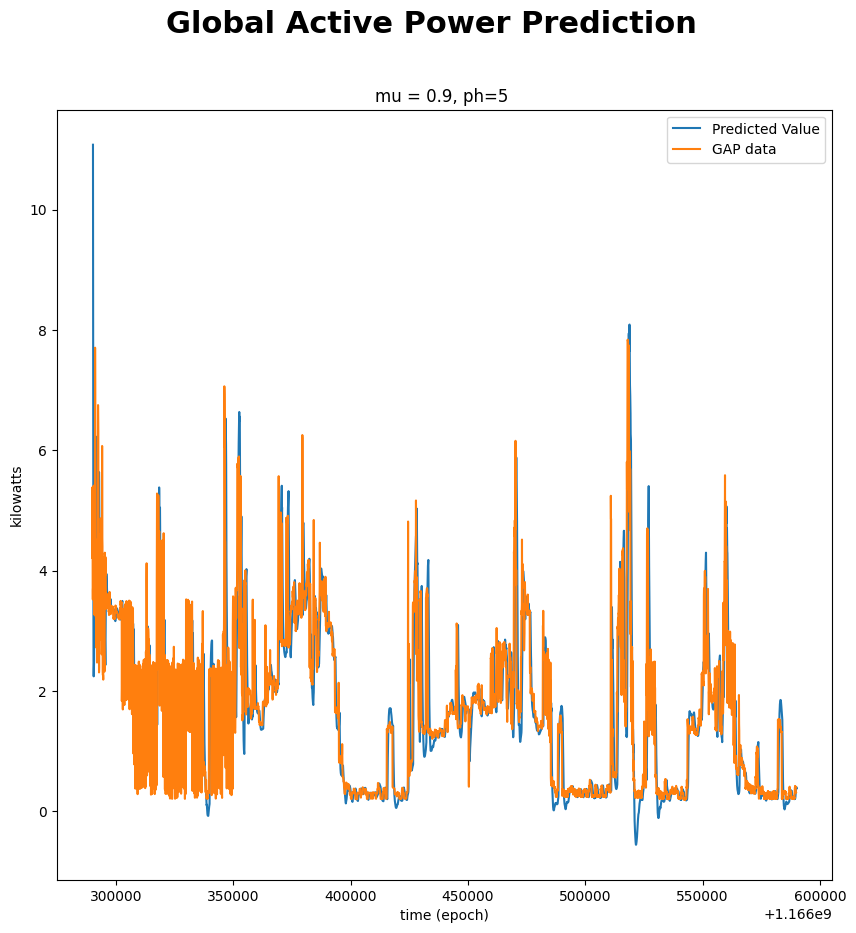

In [9]:
fig, ax = plt.subplots(figsize=(10,10))
fig.suptitle('Global Active Power Prediction', fontsize=22, fontweight='bold')
ax.set_title('mu = %g, ph=%g ' %(mu, ph))
ax.plot(tp_pred, yp_pred, label='Predicted Value')
ax.plot(ts.iloc[0:n_s,0], ys.iloc[0:n_s,0], label='GAP data')
ax.set_xlabel('time (epoch)')
ax.set_ylabel('kilowatts')
ax.legend()

It's difficult to tell how the model is performing from this plot.

**TODO: Modify the code above to visualize the first and last 200 datapoints/predictions (can be in separate charts) and compute the MSE for our predictions.**

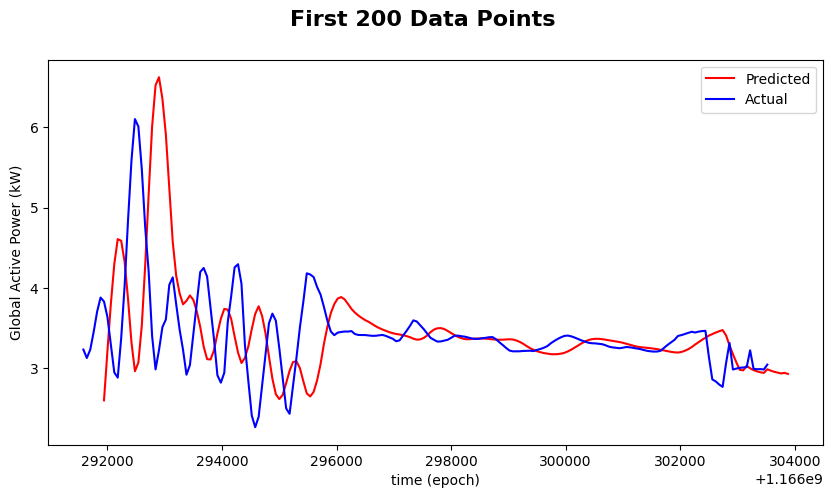

In [31]:
#Plot first 200 data points/predictions

# Number of points to plot
points_to_show = 200

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("First 200 Data Points", fontsize=16, fontweight="bold")

# Plot the first 200 predicted points
ax.plot(tp_pred[:points_to_show], yp_pred[:points_to_show], label='Predicted', color='red')

# Plot the first 200 actual points
ax.plot(ts.iloc[:points_to_show, 0], ys.iloc[:points_to_show, 0], label='Actual', color='blue')

ax.set_xlabel('time (epoch)')
ax.set_ylabel('Global Active Power (kW)')
ax.legend()
plt.show()

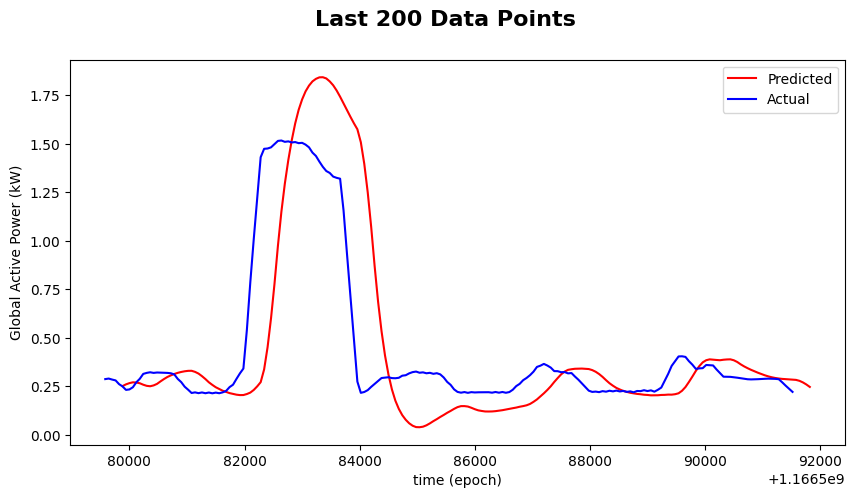

In [32]:
#Plot last 200 data points/predictions
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("Last 200 Data Points", fontsize=16, fontweight="bold")

# Plot the last 200 predicted points
ax.plot(tp_pred[-points_to_show:], yp_pred[-points_to_show:], label='Predicted', color='red')

# Plot the last 200 actual points
ax.plot(ts.iloc[n_s - points_to_show:n_s, 0], ys.iloc[n_s - points_to_show:n_s, 0],
        label='Actual', color='blue')

ax.set_xlabel('time (epoch)')
ax.set_ylabel('Global Active Power (kW)')
ax.legend()
plt.show()

In [12]:
#Calculate MSE of predictions
print("MSE is", mse(ys['Global_active_power'][ph_index:5000+ph_index-1],yp_pred))

MSE is 0.5987740533898929


**Q: How did our model perform? What do you observe on the charts? Is there a difference between the early and the late predictions? What does the MSE tell you?**

A: This model tracks the real power usage pretty well, though it occasionally misses big spikes—especially in the later part of the data where the actual values swing more. Early on, the model and actual data sometimes line up well but can drift at sudden changes. The ***MSE of about 0.59*** shows the errors aren’t huge overall, yet there’s room for improvement, particularly if the real values jump quick.

**TODO: Re-run the prediction code with mu = 1 and mu = 0.01. Use the cells below to produce charts for the first and last 200 points and to compute the MSE for each of these sets of predictions.**

In [13]:
#Re-run prediction code for mu = 1
mu = 1
tp_pred_mu1, yp_pred_mu1 = run_streaming_regression(ts, ys, n_s, ph, mu)

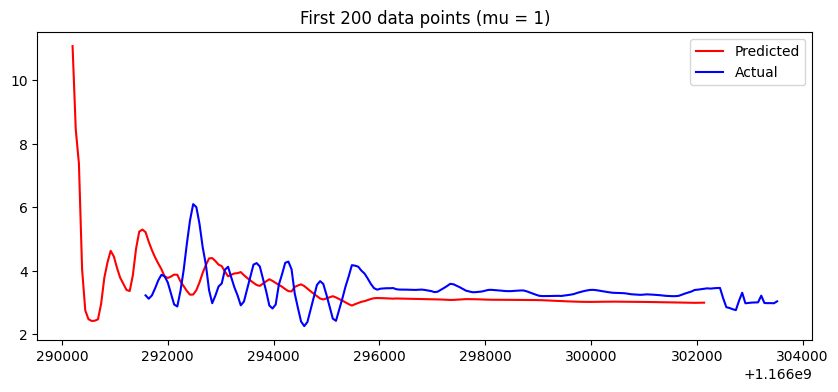

In [33]:
#Plot first 200 data points/predictions for mu = 1
plt.figure(figsize=(10,4))
plt.title("First 200 data points (mu = 1)")
plt.plot(tp_pred_mu1[:200], yp_pred_mu1[:200], 'r', label="Predicted")
plt.plot(ts.iloc[:200, 0], ys.iloc[:200, 0], 'b', label="Actual")
plt.legend()
plt.show()

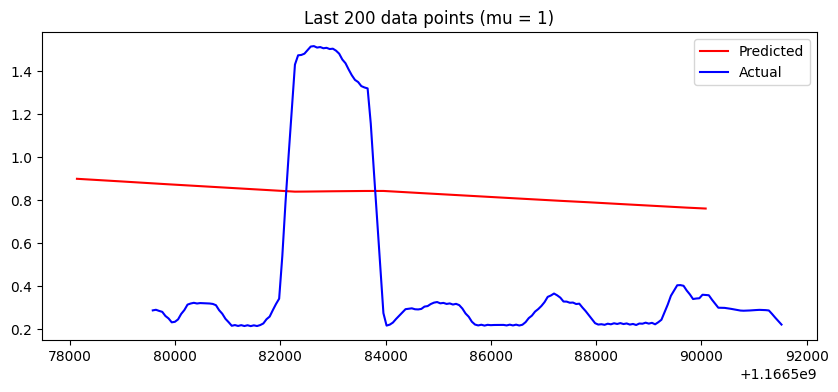

In [34]:
#Plot last 200 data points/predictions for mu = 1
plt.figure(figsize=(10,4))
plt.title("Last 200 data points (mu = 1)")
plt.plot(tp_pred_mu1[-200:], yp_pred_mu1[-200:], 'r', label="Predicted")
plt.plot(ts.iloc[n_s-200:n_s, 0], ys.iloc[n_s-200:n_s, 0], 'b', label="Actual")
plt.legend()
plt.show()

In [16]:
#Calculate MSE of predictions for mu = 1
actual_segment = ys.iloc[ph_index : (n_s + ph_index - 1), 0].values
pred_segment = yp_pred_mu1[:n_s - 1]
score_mu1 = mse(actual_segment, pred_segment)
print("MSE (mu=1):", score_mu1)

MSE (mu=1): 1.4433474819593302


In [17]:
#Re-run prediction code for mu = 0.01
mu = 0.01
tp_pred_mu001, yp_pred_mu001 = run_streaming_regression(ts, ys, n_s, ph, mu)

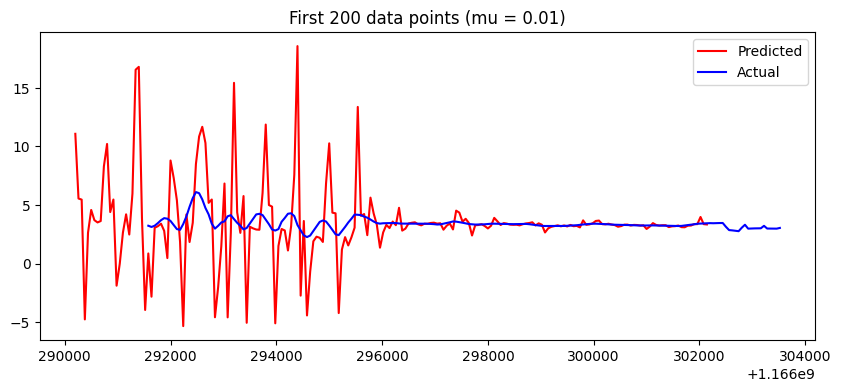

In [35]:
#Plot first 200 data points/predictions for mu = 0.01
plt.figure(figsize=(10,4))
plt.title("First 200 data points (mu = 0.01)")
plt.plot(tp_pred_mu001[:200], yp_pred_mu001[:200], 'r', label="Predicted")
plt.plot(ts.iloc[:200, 0], ys.iloc[:200, 0], 'b', label="Actual")
plt.legend()
plt.show()

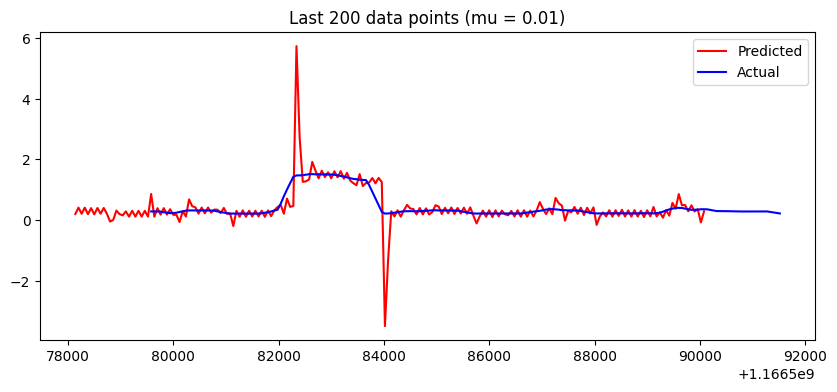

In [36]:
#Plot last 200 data points/predictions for mu = 0.01
plt.figure(figsize=(10,4))
plt.title("Last 200 data points (mu = 0.01)")
plt.plot(tp_pred_mu001[-200:], yp_pred_mu001[-200:], 'r', label="Predicted")
plt.plot(ts.iloc[n_s-200:n_s, 0], ys.iloc[n_s-200:n_s, 0], 'b', label="Actual")
plt.legend()
plt.show()

In [20]:
#Calculate MSE of predictions for mu = 0.01
actual_segment = ys.iloc[ph_index : (n_s + ph_index - 1), 0].values
pred_segment = yp_pred_mu001[:n_s - 1]
score_mu001 = mse(actual_segment, pred_segment)
print("MSE (mu=0.01):", score_mu001)

MSE (mu=0.01): 7.985307094756632


**Q: How did our mu = 1 model perform? What do you observe on the charts? Is there a difference between the early and the late predictions? What does the MSE tell you?**

A: The model never forgets old data, so it relies on the entire historical dataset equally. From the charts, early predictions and actual values can diverge somewhat but eventually appear smoother. The MSE of about 1.44 indicates moderate error: the model captures the broader trend yet struggles with sudden shifts.

**Q: How did our mu = 0.01 model perform? What do you observe on the charts? Is there a difference between the early and the late predictions? What does the MSE tell you?**

A: The model heavily weights the newest data and almost ignores older points. The plots reveal more dramatic swings in predicted values—especially early on—leading to an MSE around 7.99, which suggests it’s too reactive and not stable for larger trends.

**Q: Which of these three models is the best? How do you know? Why does this make sense based on the mu parameter used?**

A: model is best because it yields the lowest MSE (around 0.59). It balances old and new data more effectively than the extremes of mu=1 or mu=0.01. This makes sense because *mu* close to 1 preserves the entire history, and a very small *mu* discards past information too quickly, making the model overly erratic.

**Q: What could we do to improve our model and/or make it more realistic and useful?**

A: We might add features like voltage or external factors, like temperature or time-of-day effects, use rolling windows instead of exponential forgetting, or incorporate regularization for stability. Fine-tuning the predictive horizon or combining this linear model with domain-specific insights could also boost accuracy.

**TODO: Add voltage data as a second variable to our model and re-run the prediction code. Then visualize the first and last 200 points and compute the MSE**

In [21]:
#add voltage to the x-variables in our dataset
ts = pd.DataFrame({'unix': df['unix'], 'Voltage': df['Voltage']})
ys = pd.DataFrame(df['Global_active_power'])

ph = 5#5 minutes
ph_index = ph
mu = 0.9

#let's limit the number of samples in our model to 5000 just for speed
n_s = 5000

#arrays to hold predicted values
tp_pred = np.zeros(n_s-1)
yp_pred = np.zeros(n_s-1)

In [22]:
#run the prediction code on your expanded dataset
#make sure to adjust your yp prediction to include the coefficients from time AND voltage
tp_pred_expanded = np.zeros(n_s - 1)
yp_pred_expanded = np.zeros(n_s - 1)

for i in range(2, n_s + 1):
    # Slice up to the i-th row
    X_tmp = ts.iloc[:i].values  # shape => (i, 2): [unix, Voltage]
    y_tmp = ys.iloc[:i, 0].values

    ns = len(y_tmp)

    # Build the forgetting-factor weights
    weights = np.ones(ns) * mu
    for k in range(ns):
        weights[k] = mu ** k
    weights = np.flip(weights, 0)

    # Fit weighted linear regression
    lm_tmp = LinearRegression()
    lm_tmp.fit(X_tmp, y_tmp, sample_weight=weights)

    # Extract two slopes + intercept
    m_time, m_volt = lm_tmp.coef_
    intercept = lm_tmp.intercept_

    # Predict ph minutes ahead
    last_time = X_tmp[-1, 0]       # last known time in seconds
    last_voltage = X_tmp[-1, 1]    # last known voltage
    future_time = last_time + (ph * 60)  # add 5 minutes (in seconds)

    # Assume voltage remains the same as last known
    yp = (m_time * future_time) + (m_volt * last_voltage) + intercept

    # Store predictions
    tp_pred_expanded[i - 2] = future_time
    yp_pred_expanded[i - 2] = yp

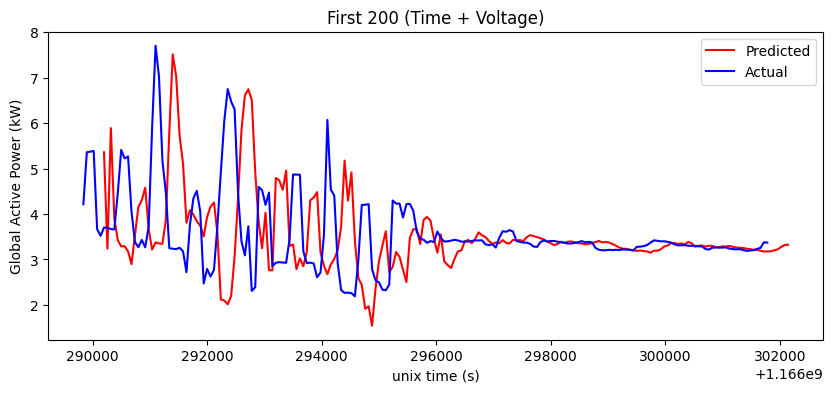

In [23]:
#Plot first 200 data points/predictions for the expanded dataset
points_to_show = 200

plt.figure(figsize=(10,4))
plt.title("First 200 (Time + Voltage)")
plt.plot(tp_pred_expanded[:points_to_show], yp_pred_expanded[:points_to_show], 'r', label="Predicted")
plt.plot(ts.iloc[:points_to_show, 0], ys.iloc[:points_to_show, 0], 'b', label="Actual")
plt.xlabel("unix time (s)")
plt.ylabel("Global Active Power (kW)")
plt.legend()
plt.show()

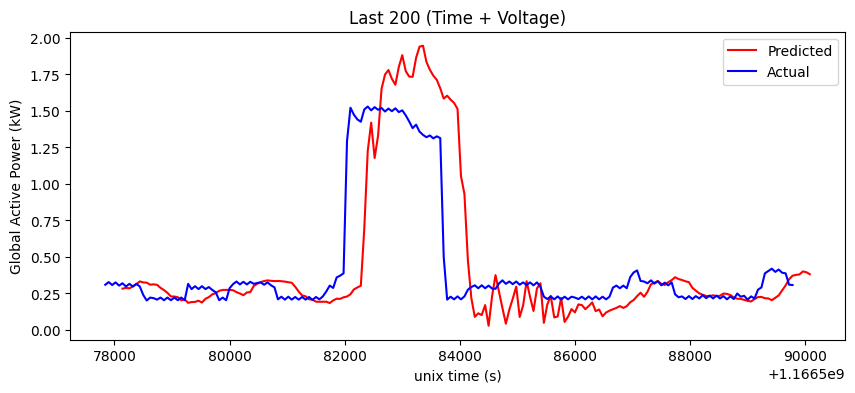

In [24]:
#Plot last 200 data points/predictions for the expanded data
plt.figure(figsize=(10,4))
plt.title("Last 200 (Time + Voltage)")
plt.plot(tp_pred_expanded[-points_to_show:], yp_pred_expanded[-points_to_show:], 'r', label="Predicted")
plt.plot(ts.iloc[n_s - points_to_show:n_s, 0], ys.iloc[n_s - points_to_show:n_s, 0], 'b', label="Actual")
plt.xlabel("unix time (s)")
plt.ylabel("Global Active Power (kW)")
plt.legend()
plt.show()

In [25]:
#Calculate MSE of predictions for the expanded data
actual_segment = ys.iloc[ph_index : (n_s + ph_index - 1), 0].values
pred_segment = yp_pred_expanded[:n_s - 1]
score_expanded = mse(actual_segment, pred_segment)
print("MSE (Time + Voltage):", score_expanded)

MSE (Time + Voltage): 0.596993465766244


**Q: How did the model performed when you added the voltage data? How does it compare to the models without it?**

A: Adding voltage as a second feature slightly improved the prediction accuracy, reflected in a modestly lower MSE (around 0.60). It appears that having both time and voltage helps the model track changes in power usage a bit better than using time alone.

There are lots of other ways that we could try to improve our model while still using linear regression.

**TODO: Choose one alternative model and re-run the prediction code. Some ideas include:**

- Use a moving average as the response variable
- Make your prediction based on the time of day instead of as a continuous time series
- Use a moving window to limit your predictions instead of using a mu factor

**Q: Describe your alternative model and why it might improve your model**

A: One alternative is to *use a moving average for the response variable* instead of the raw power readings. This smoothing step helps reduce short-term spikes or dips, so the linear model is trained on a more stable target. In theory, that can lower the noise the model has to fit and potentially yield more consistent predictions—especially if abrupt fluctuations are less important than overall trends.

In [26]:
#create your alternative training data here
df['GAP_smooth'] = df['Global_active_power'].rolling(window=5).mean()
df.dropna(inplace=True)

# Define new x (time) and y (smoothed GAP)
ts = pd.DataFrame({'unix': df['unix']})
ys = pd.DataFrame(df['GAP_smooth'])

ph = 5 #5 minutes
ph_index = ph
mu = 0.9

#let's limit the number of samples in our model to 5000 just for speed
n_s = 5000

#arrays to hold predicted values
#you may need to adjust these
tp_pred = np.zeros(n_s-1)
yp_pred = np.zeros(n_s-1)

In [27]:
#re-run the prediction code here
for i in range(2, n_s + 1):
    # Slice up to the i-th row
    ts_tmp = ts.iloc[:i, 0].values.reshape(-1, 1)  # shape => (i, 1)
    ys_tmp = ys.iloc[:i, 0].values  # smoothed GAP
    ns = len(ys_tmp)

    # Build forgetting-factor weights
    weights = np.ones(ns) * mu
    for k in range(ns):
        weights[k] = mu ** k
    weights = np.flip(weights, 0)

    # Fit Weighted Linear Regression
    lm_tmp = LinearRegression()
    lm_tmp.fit(ts_tmp, ys_tmp, sample_weight=weights)

    # Extract slope & intercept
    m_tmp = lm_tmp.coef_[0]
    q_tmp = lm_tmp.intercept_

    # Predict ph minutes ahead (assuming 'unix' in seconds)
    last_time = ts_tmp[-1, 0]
    future_time = last_time + (ph * 60)
    yp = (m_tmp * future_time) + q_tmp

    # Store predicted time and smoothed GAP
    tp_pred[i - 2] = future_time
    yp_pred[i - 2] = yp

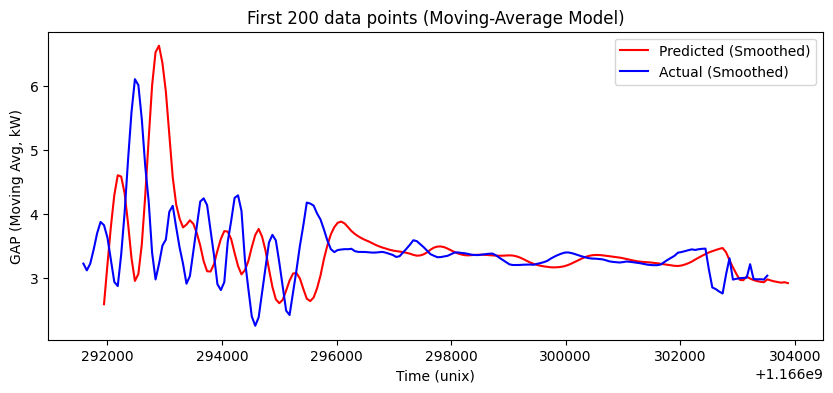

In [37]:
#Plot first 200 data points/predictions for alternative model
points_to_show = 200

plt.figure(figsize=(10, 4))
plt.title("First 200 data points (Moving-Average Model)")
plt.plot(tp_pred[:points_to_show], yp_pred[:points_to_show], label="Predicted (Smoothed)", color="red")
plt.plot(ts.iloc[:points_to_show, 0], ys.iloc[:points_to_show, 0], label="Actual (Smoothed)", color="blue")
plt.xlabel("Time (unix)")
plt.ylabel("GAP (Moving Avg, kW)")
plt.legend()
plt.show()

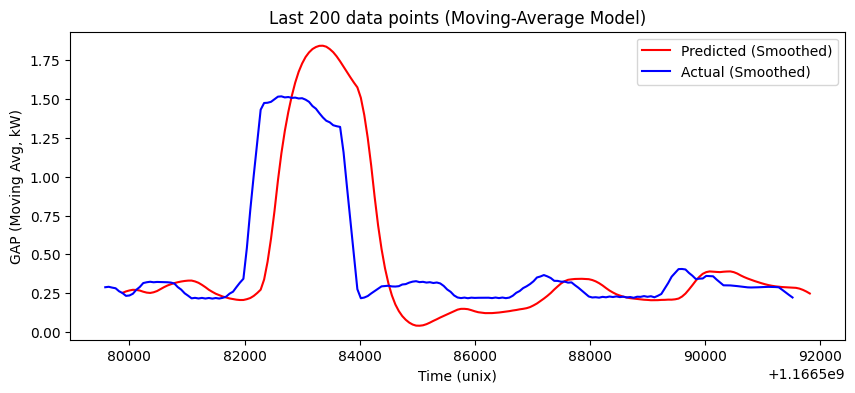

In [39]:
#Plot last 200 data points/predictions for alternative model
plt.figure(figsize=(10, 4))
plt.title("Last 200 data points (Moving-Average Model)")
plt.plot(tp_pred[-points_to_show:], yp_pred[-points_to_show:], label="Predicted (Smoothed)", color="red")
plt.plot(ts.iloc[n_s - points_to_show:n_s, 0], ys.iloc[n_s - points_to_show:n_s, 0], label="Actual (Smoothed)", color="blue")
plt.xlabel("Time (unix)")
plt.ylabel("GAP (Moving Avg, kW)")
plt.legend()
plt.show()

In [30]:
#Calculate MSE of predictions for alternative model
actual_segment = ys.iloc[ph_index : (n_s + ph_index - 1), 0].values
pred_segment = yp_pred[:n_s - 1]
score_alt = mse(actual_segment, pred_segment)
print("MSE (Alternative Model, Moving Avg):", score_alt)

MSE (Alternative Model, Moving Avg): 0.3788888891170863


**Q: Did your alternative model improve on our previous results? What else could you do to improve the model while still using linear regression?**

A: Yes, using a moving average for the target noticeably lowered the MSE to around 0.38, and the plots show a smoother fit with fewer wild swings. However, there are still some mismatches during sharp peaks and valleys. To further improve the model—while sticking with linear regression—we could add more relevant features, explore polynomial or interaction terms, or adopt a rolling window approach in place of exponential forgetting for even more control over how older data is weighted.